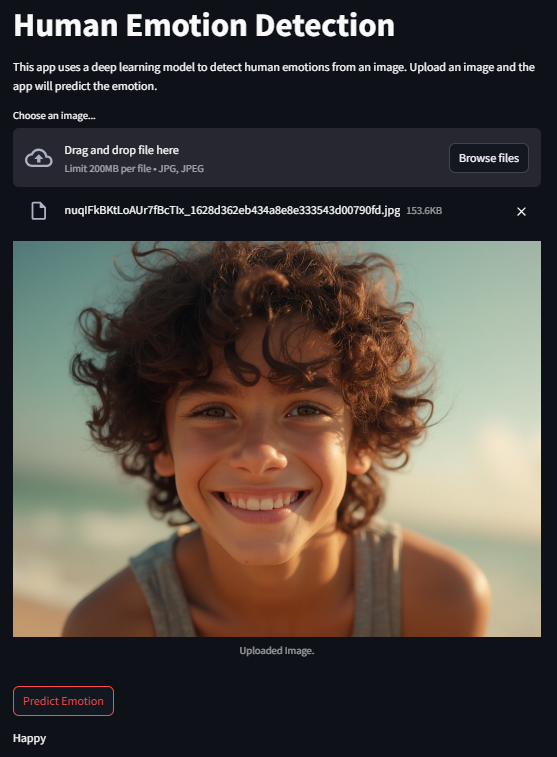


## https://human-emotions.streamlit.app/

# 💾 Data
The FER-2013 dataset consists of 48x48 pixel grayscale images of faces. The dataset contains 24,400 images, with 22,968 examples in the training set and 1,432 examples in the public test set.

# 🖼️ Data Exploration 

Found 22968 images belonging to 7 classes.
Found 1432 images belonging to 7 classes.


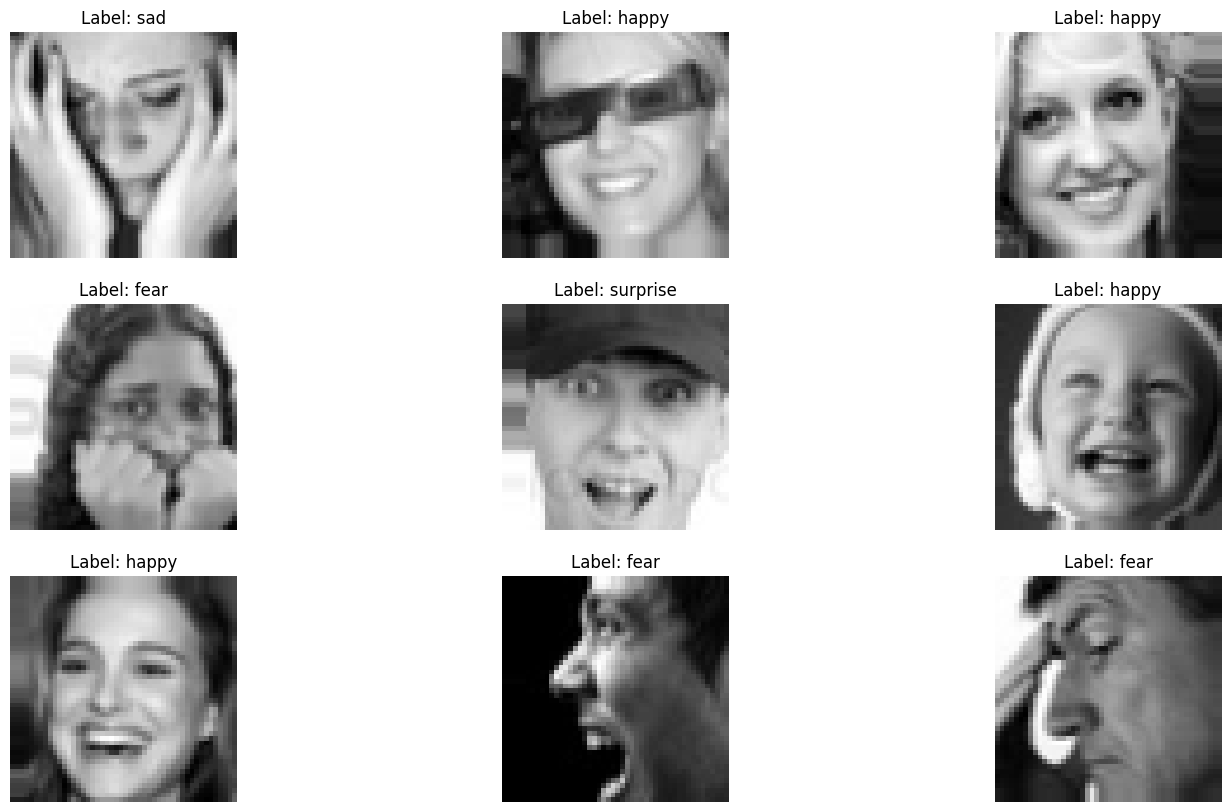

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load FER-2013 dataset
train_dir = "../input/fer2013/train"
test_dir = "../input/fer2013/test"

# Data generators with augmentation
train_datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    rescale=1./255,
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

# Get class names
class_names = list(train_generator.class_indices.keys())

# Visualize some samples
def visualize_samples(generator):
    x_batch, y_batch = next(generator)
    plt.figure(figsize=(18, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(x_batch[i].reshape(48, 48), cmap='gray')
        label_index = np.argmax(y_batch[i])
        plt.title(f"Label: {class_names[label_index]}")
        plt.axis('off')
    plt.show()

visualize_samples(train_generator)

# 🧠 Model Training & Testing : Vision Transformer (ViT)

In [2]:
!pip install tensorflow tensorflow-addons transformers

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 10.8 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.3.0
    Uninstalling typeguard-4.3.0:
      Successfully uninstalled typeguard-4.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.9.0 requires scipy<1.14,>=1.4.1, but you have scipy 1.14.0 which is incompatible.
ydata-profiling 4.9.0 requires typeguard<5,>=3, but you have typeguard 2.13.3 which is incompatible.


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


Best model saved at epoch 1 with validation accuracy: 0.6517
Epoch 1/4
Train Loss: 1.0624, Train Accuracy: 0.6056
Val Loss: 0.9300, Val Accuracy: 0.6517
Best model saved at epoch 2 with validation accuracy: 0.6825
Epoch 2/4
Train Loss: 0.7796, Train Accuracy: 0.7167
Val Loss: 0.8642, Val Accuracy: 0.6825
Best model saved at epoch 3 with validation accuracy: 0.7080
Epoch 3/4
Train Loss: 0.4588, Train Accuracy: 0.8480
Val Loss: 0.8273, Val Accuracy: 0.7080
Best model saved at epoch 4 with validation accuracy: 0.7126
Epoch 4/4
Train Loss: 0.3424, Train Accuracy: 0.8934
Val Loss: 0.8665, Val Accuracy: 0.7126


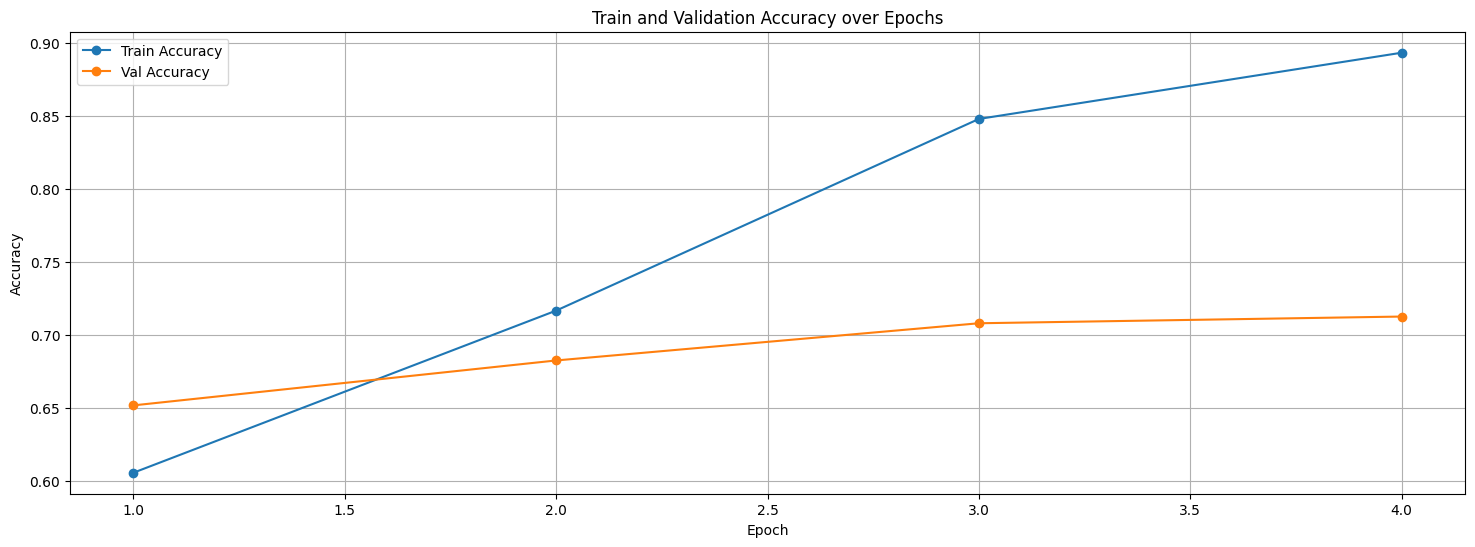

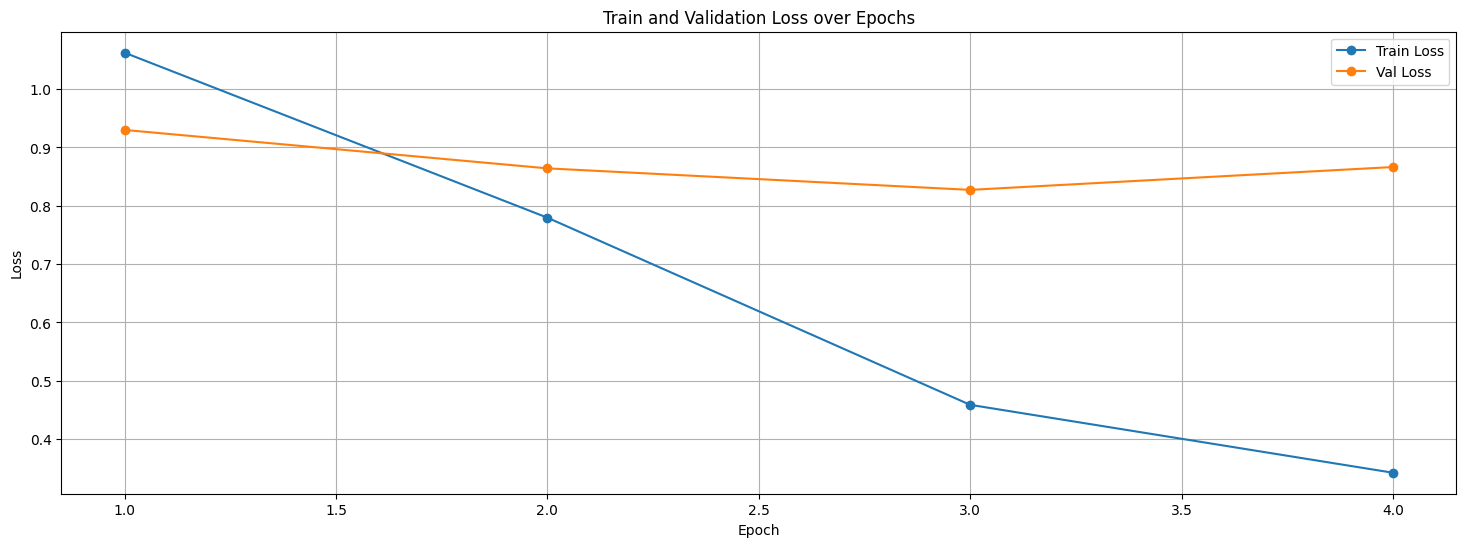

In [3]:
import torch
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import ViTFeatureExtractor, ViTForImageClassification
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the pre-trained Vision Transformer model
model_name = 'google/vit-base-patch16-224-in21k'
model = ViTForImageClassification.from_pretrained(model_name, num_labels=7)  # 7 classes for FER-2013
model.to(device)  # Move model to GPU

# Load the feature extractor
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)

# Define transformations for the training and validation sets
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = datasets.ImageFolder(root='../input/fer2013/train', transform=transform)
val_dataset = datasets.ImageFolder(root='../input/fer2013/test', transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = F.cross_entropy

# Optional: Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

# Training and evaluation functions
def train_one_epoch(model, train_loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = model(images).logits  # Extract logits from the model output
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(train_loader), correct / total

def evaluate(model, val_loader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to GPU
            outputs = model(images).logits  # Extract logits from the model output
            loss = loss_fn(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(val_loader), correct / total

# Lists to store accuracy and loss values
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

best_val_acc = 0.0  # Initialize the best validation accuracy
best_model_path = 'best_vit_fer2013_model.pt'  # File to save the best model

num_epochs = 4
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn)
    
    # Store the losses and accuracies
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    # Save the model if the current validation accuracy is the best so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model, best_model_path)  # Save the best model
        print(f"Best model saved at epoch {epoch+1} with validation accuracy: {val_acc:.4f}")
    
    # Update the learning rate
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

# Plotting the accuracy graph
plt.figure(figsize=(18, 6))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy', marker='o')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Val Accuracy', marker='o')
plt.title('Train and Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the loss graph
plt.figure(figsize=(18, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss', marker='o')
plt.title('Train and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

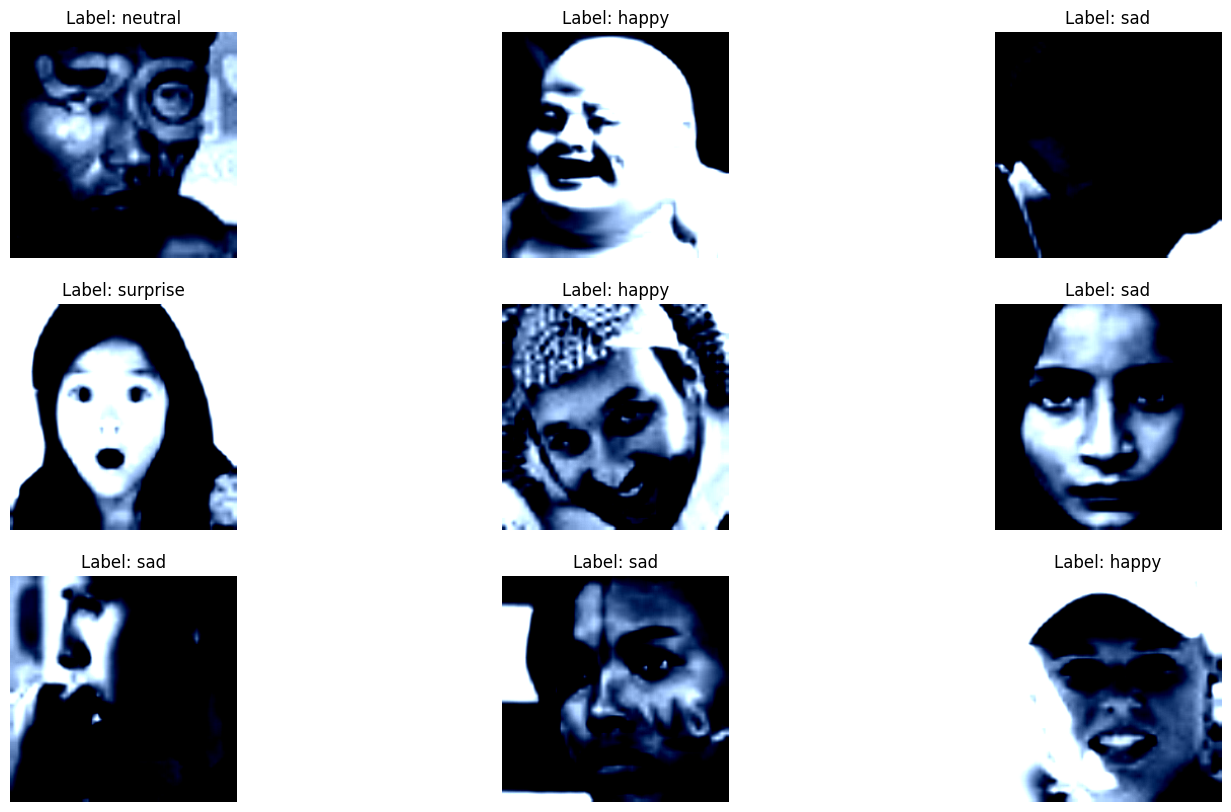

In [4]:
# Visualize some samples from the training set
def visualize_samples(loader):
    x_batch, y_batch = next(iter(loader))
    x_batch = x_batch.to('cpu')  # Move images to CPU for visualization
    batch_size = x_batch.size(0)  # Get the actual batch size
    
    plt.figure(figsize=(18, 10))
    for i in range(9):  # Ensure we don't exceed the batch size
        plt.subplot(3, 3, i+1)
        plt.imshow(x_batch[i].permute(1, 2, 0).numpy())
        label_index = y_batch[i].item()  # Convert to a single integer
        plt.title(f"Label: {train_dataset.classes[label_index]}")
        plt.axis('off')
    plt.show()
visualize_samples(train_loader)